Archivos encontrados:
0: stroma_ad_dysplasia_FA_HN11A_5.csv
1: dysplasia_FA_HN11A_1.csv
2: carcinoma_FA_HN14_2.csv
3: stroma_ad_carcinoma_FA_HN14_3.csv

Procesando: stroma_ad_dysplasia_FA_HN11A_5.csv
Número de puntos: 1049


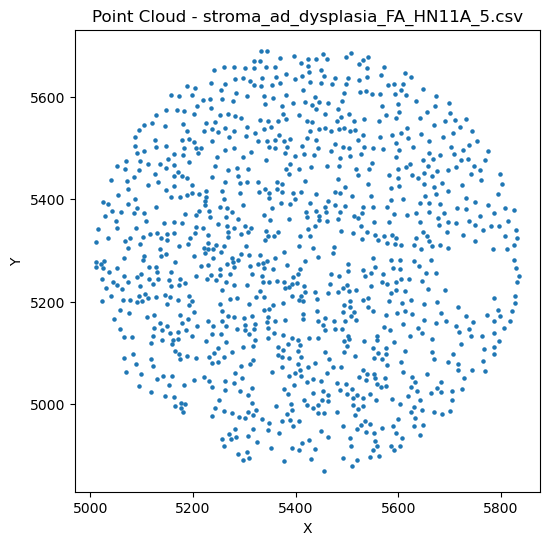

Número de simplices: 368631


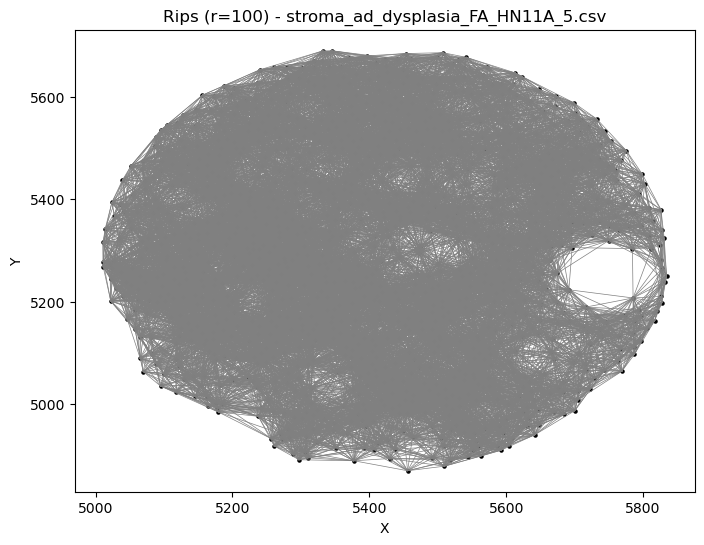

usetex mode requires TeX.


Primeros valores:
[(1, (28.93167709459221, inf)), (1, (25.974917831490373, 59.44069934653981)), (1, (28.633869448627546, 61.68222117418402)), (1, (27.41863801437961, 58.64154776201419)), (1, (27.48526939433311, 58.011612321714566))]


<Figure size 600x600 with 0 Axes>

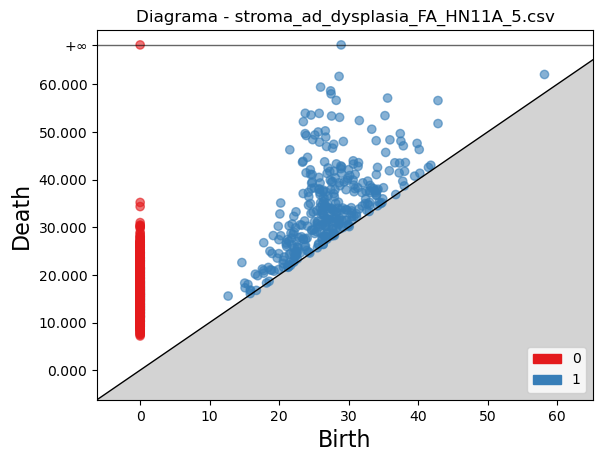

Guardado en: /home/jupyter-luisraul/tda-cell-patterns-workshop/data/resultados/stroma_ad_dysplasia_FA_HN11A_5_diag.csv

Procesando: dysplasia_FA_HN11A_1.csv
Número de puntos: 1035


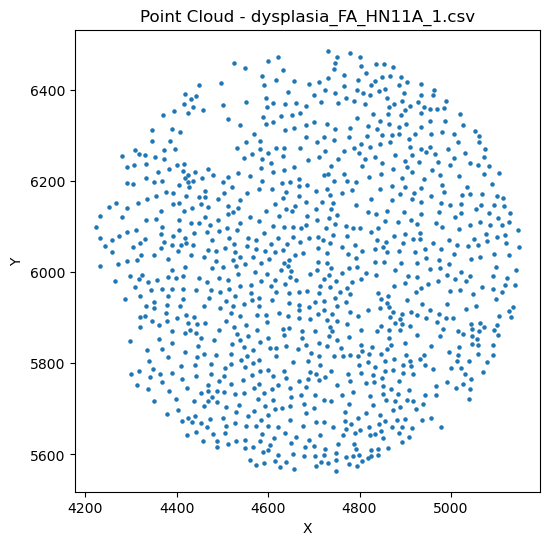

Número de simplices: 235296


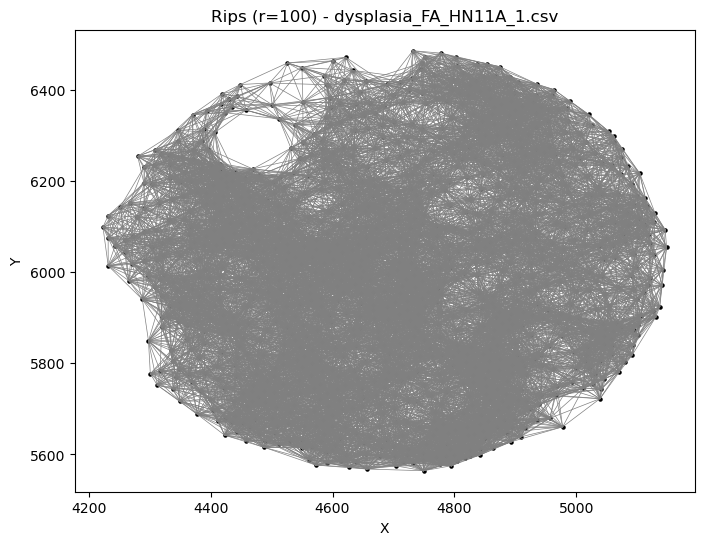

Primeros valores:
[(1, (44.50575239622595, inf)), (1, (26.8677093770225, 61.71119279828924)), (1, (28.711268461412047, 60.45659874631934)), (1, (28.762301689860433, 60.02275215393967)), (1, (28.719254671347294, 57.49479262720702))]


<Figure size 600x600 with 0 Axes>

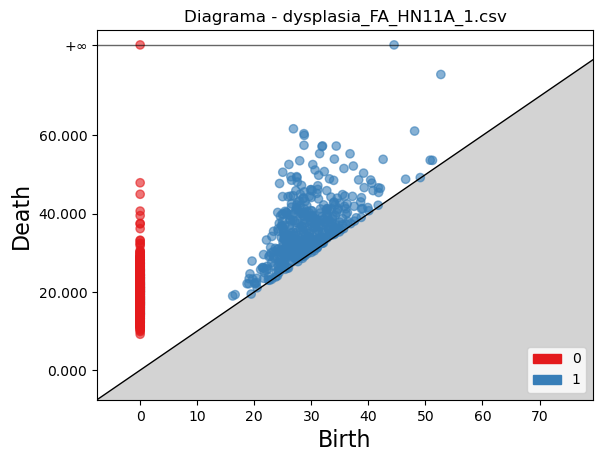

Guardado en: /home/jupyter-luisraul/tda-cell-patterns-workshop/data/resultados/dysplasia_FA_HN11A_1_diag.csv

Procesando: carcinoma_FA_HN14_2.csv
Número de puntos: 1030


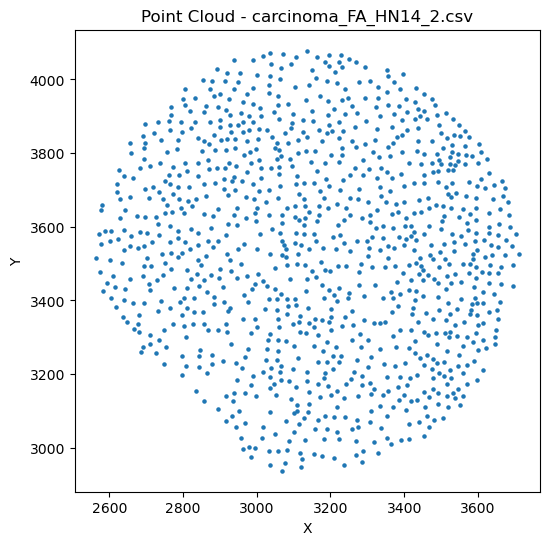

Número de simplices: 107036


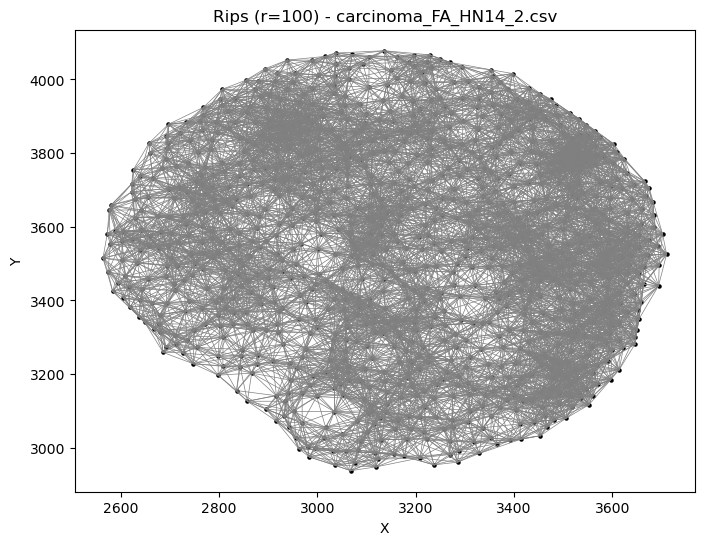

Primeros valores:
[(1, (31.80289949119616, 77.65066582721188)), (1, (39.23315548111529, 78.14230316856788)), (1, (32.372198157574125, 68.30224655762743)), (1, (32.09901452219987, 67.65712064701079)), (1, (33.66047254900323, 68.10880650876429))]


<Figure size 600x600 with 0 Axes>

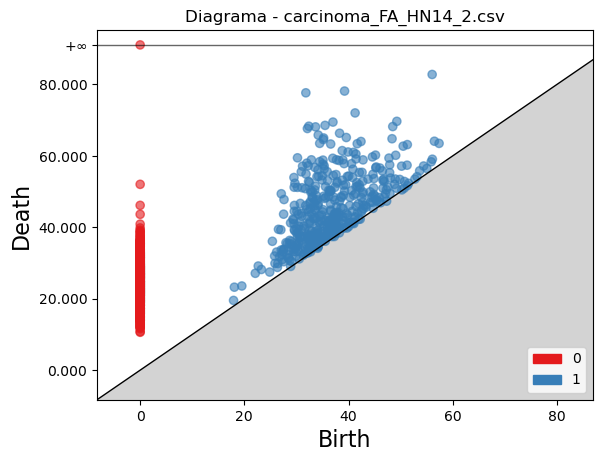

Guardado en: /home/jupyter-luisraul/tda-cell-patterns-workshop/data/resultados/carcinoma_FA_HN14_2_diag.csv

Procesando: stroma_ad_carcinoma_FA_HN14_3.csv
Número de puntos: 1045


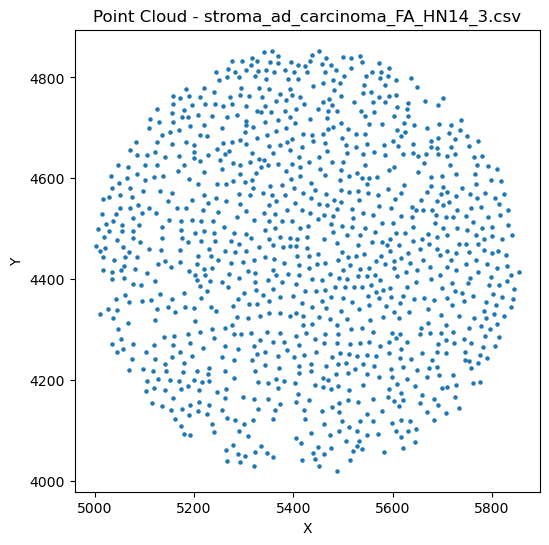

Número de simplices: 311072


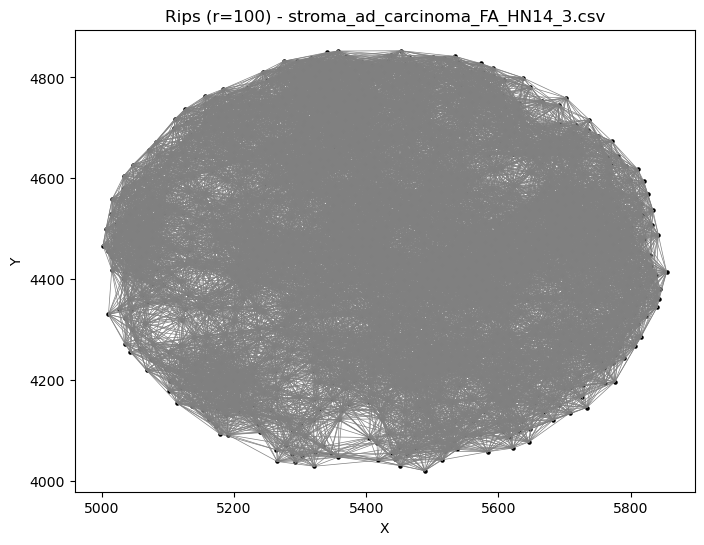

Primeros valores:
[(1, (29.29065448908302, 65.39919075948575)), (1, (26.878732820845986, 57.955575724171666)), (1, (26.64458660015346, 53.47635977290165)), (1, (24.42163190333645, 50.40255261070409)), (1, (24.22108319490209, 49.65612905611709))]


<Figure size 600x600 with 0 Axes>

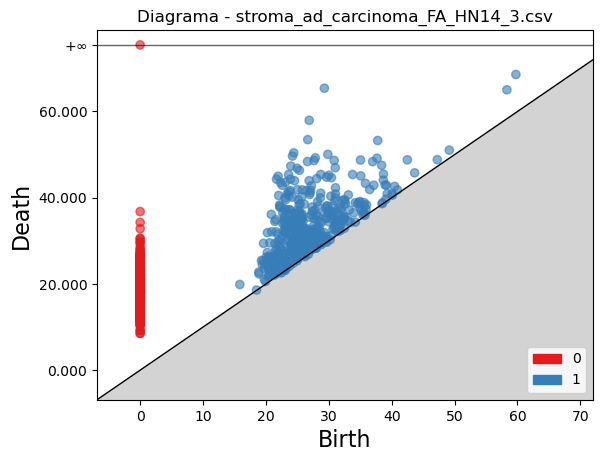

Guardado en: /home/jupyter-luisraul/tda-cell-patterns-workshop/data/resultados/stroma_ad_carcinoma_FA_HN14_3_diag.csv


In [1]:
# ============================================================
# 1. IMPORTACIONES
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gudhi as gd


# ============================================================
# 2. DEFINIR SOLO LA RUTA
# ============================================================
ruta = "/home/jupyter-luisraul/tda-cell-patterns-workshop/data/"
radio = 100  # valor ya definido


# ============================================================
# 3. DETECTAR ARCHIVOS CSV
# ============================================================
archivos = [f for f in os.listdir(ruta) if f.endswith(".csv")]

if len(archivos) == 0:
    raise ValueError("No se encontraron archivos CSV en la carpeta.")

print("Archivos encontrados:")
for i, f in enumerate(archivos):
    print(f"{i}: {f}")


# ============================================================
# 4. CARPETA DE SALIDA
# ============================================================
ruta_out = os.path.join(ruta, "resultados")
os.makedirs(ruta_out, exist_ok=True)


# ============================================================
# 5. PROCESAR TODOS LOS CSV
# ============================================================
for archivo in archivos:
    
    print(f"\nProcesando: {archivo}")
    
    ruta_completa = os.path.join(ruta, archivo)
    
    # -------------------------------
    # CARGAR DATOS
    # -------------------------------
    df = pd.read_csv(ruta_completa)

    x = df["X_centroid"].to_numpy()
    y = df["Y_centroid"].to_numpy()

    puntos = np.column_stack((x, y))

    print(f"Número de puntos: {len(puntos)}")


    # -------------------------------
    # VISUALIZAR POINT CLOUD
    # -------------------------------
    plt.figure(figsize=(6,6))
    plt.scatter(x, y, s=5)
    plt.title(f"Point Cloud - {archivo}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()


    # -------------------------------
    # COMPLEJO DE RIPS
    # -------------------------------
    rips_complex = gd.RipsComplex(points=puntos, max_edge_length=radio)
    simplex_tree = rips_complex.create_simplex_tree(max_dimension=2)

    print("Número de simplices:", simplex_tree.num_simplices())


    # -------------------------------
    # VISUALIZAR COMPLEJO
    # -------------------------------
    plt.figure(figsize=(8,6))
    plt.scatter(x, y, color="black", s=5)

    for simplex in simplex_tree.get_skeleton(1):
        if len(simplex[0]) == 2:
            i, j = simplex[0]
            plt.plot([x[i], x[j]], [y[i], y[j]], color="gray", linewidth=0.5)

    plt.title(f"Rips (r={radio}) - {archivo}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()


    # -------------------------------
    # HOMOLOGÍA PERSISTENTE
    # -------------------------------
    diag = simplex_tree.persistence()

    print("Primeros valores:")
    print(diag[:5])


    # -------------------------------
    # DIAGRAMA DE PERSISTENCIA
    # -------------------------------
    plt.figure(figsize=(6,6))
    gd.plot_persistence_diagram(diag)
    plt.title(f"Diagrama - {archivo}")
    plt.show()


    # -------------------------------
    # GUARDAR RESULTADOS
    # -------------------------------
    output = pd.DataFrame(
        [[dim, b, d] for dim, (b, d) in diag if dim <= 2],
        columns=["dimension", "birth", "death"]
    )

    nombre_salida = archivo.replace(".csv", "_diag.csv")
    output_path = os.path.join(ruta_out, nombre_salida)
    output.to_csv(output_path, index=False)

    print(f"Guardado en: {output_path}")

# Análisis Topológico de Datos (TDA)

En este notebook vamos a construir paso a paso:

1. Una nube de puntos a partir de coordenadas celulares  
2. Un complejo de Rips  
3. El diagrama de persistencia  

La idea es entender cómo pasamos de datos espaciales a descriptores topológicos.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gudhi as gd

## 1. Cargar datos

Vamos a trabajar con un archivo CSV que contiene coordenadas de centroides celulares:

- X_centroid  
- Y_centroid  

Esto representa nuestra nube de puntos (point cloud).

In [6]:
ruta = "/home/jupyter-luisraul/tda-cell-patterns-workshop/data/carcinoma_FA_HN14_2.csv"  # puedes cambiar este valor

df = pd.read_csv(ruta)

x = df["X_centroid"].to_numpy()
y = df["Y_centroid"].to_numpy()

puntos = np.column_stack((x, y))

print(f"Número de puntos: {len(puntos)}")

Número de puntos: 1030


## 2. Visualización de la nube de puntos

Antes de aplicar TDA, es importante observar la estructura espacial de los datos.

Cada punto representa una célula en el tejido.

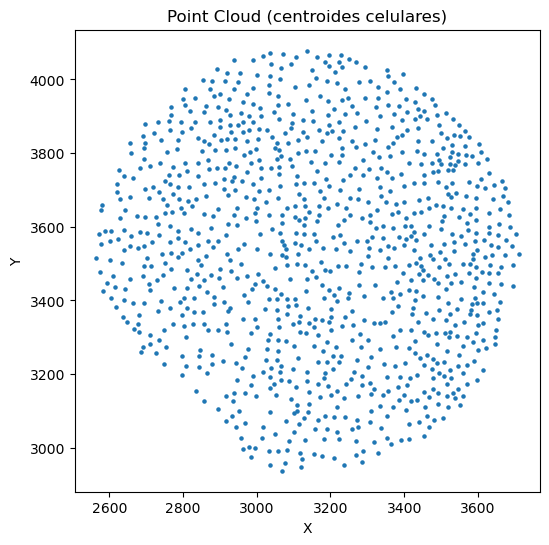

In [7]:
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=5)
plt.title("Point Cloud (centroides celulares)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

## 3. Complejo de Rips

Construimos un complejo de Rips conectando puntos que están a una distancia menor que un parámetro r.

Este parámetro controla la escala de análisis.

In [8]:
radio = 50  # puedes cambiar este valor

rips_complex = gd.RipsComplex(points=puntos, max_edge_length=radio)
simplex_tree = rips_complex.create_simplex_tree(max_dimension=2) # puedes cambiar este valor

print("Número de simplices:", simplex_tree.num_simplices())

Número de simplices: 9121


## 4. Visualización del complejo

Aquí observamos cómo se conectan los puntos.

Las líneas representan conexiones entre puntos cercanos.

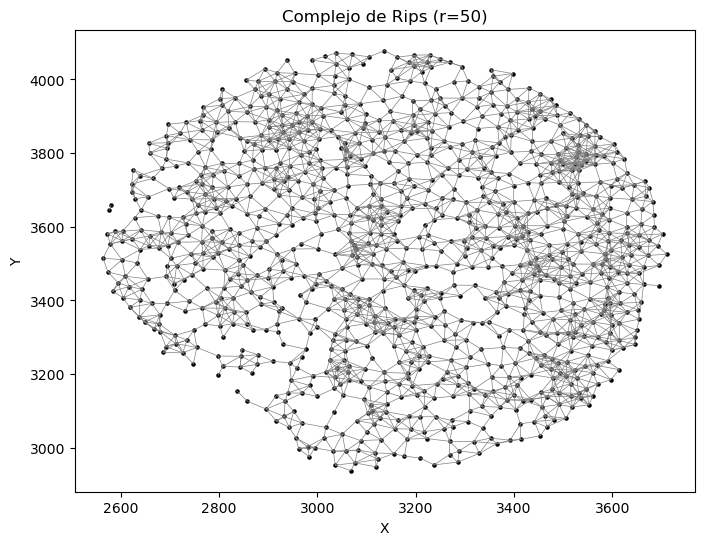

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(x, y, color="black", s=5)

for simplex in simplex_tree.get_skeleton(1):
    if len(simplex[0]) == 2:
        i, j = simplex[0]
        plt.plot([x[i], x[j]], [y[i], y[j]], color="gray", linewidth=0.5)

plt.title(f"Complejo de Rips (r={radio})")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

## 5. Homología persistente

Calculamos las características topológicas del complejo:

- Dimensión 0: componentes conexas  
- Dimensión 1: ciclos  

Estas características se analizan a lo largo de distintas escalas.

In [10]:
diag = simplex_tree.persistence()

print("Primeros valores:")
print(diag[:10])

Primeros valores:
[(1, (36.50843414019692, inf)), (1, (34.89826559940533, inf)), (1, (34.94464363154827, inf)), (1, (35.07773869438781, inf)), (1, (35.08834896071297, inf)), (1, (35.147632669852634, inf)), (1, (35.21930408753491, inf)), (1, (35.3060076839965, inf)), (1, (35.31815355881978, inf)), (1, (35.488743972397636, inf))]


## 6. Diagrama de persistencia

El diagrama muestra cuándo aparecen (birth) y desaparecen (death) las estructuras topológicas.

Cada punto representa una característica topológica.

<Figure size 600x600 with 0 Axes>

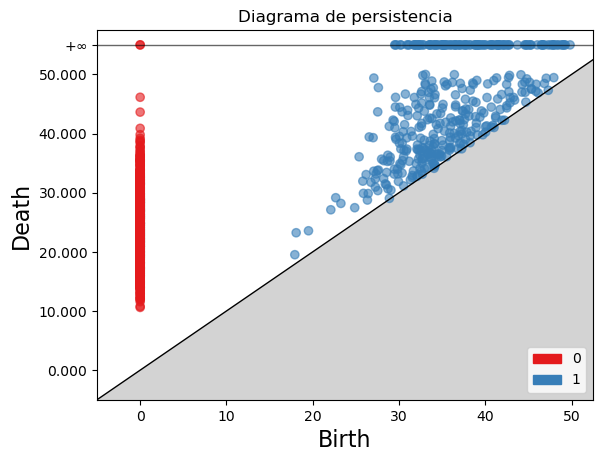

In [11]:
plt.figure(figsize=(6,6))
gd.plot_persistence_diagram(diag)
plt.title("Diagrama de persistencia")
plt.show()

## 7. Guardar resultados

Guardamos el diagrama como tabla para análisis posterior.

In [12]:
output = pd.DataFrame(
    [[dim, b, d] for dim, (b, d) in diag if dim <= 2],
    columns=["dimension", "birth", "death"]
)

output.head()

,dimension,birth,death
0,1,36.508434,inf
1,1,34.898266,inf
2,1,34.944644,inf
3,1,35.077739,inf
4,1,35.088349,inf


In [14]:
# Distancias-

In [5]:
# ============================================================
# 1. IMPORTACIONES
# ============================================================
import os
import numpy as np
import pandas as pd
import gudhi.wasserstein as gw


# ============================================================
# 2. DEFINIR RUTA
# ============================================================
ruta = "/home/jupyter-luisraul/tda-cell-patterns-workshop/data/resultados/"

# Aquí deben estar los CSV de diagramas
# (columnas: dimension, birth, death)


# ============================================================
# 3. VER ARCHIVOS DISPONIBLES
# ============================================================
archivos = [f for f in os.listdir(ruta) if f.endswith(".csv")]

if len(archivos) < 2:
    raise ValueError("Se necesitan al menos 2 archivos CSV.")

print("Archivos disponibles:")
for i, f in enumerate(archivos):
    print(f"{i}: {f}")


# ============================================================
# 4. SELECCIONAR DOS ARCHIVOS
# ============================================================
archivo1 = archivos[0]
archivo2 = archivos[1]

print(f"\nComparando:\n{archivo1}\n{archivo2}")


# ============================================================
# 5. CARGAR DIAGRAMAS
# ============================================================
df1 = pd.read_csv(os.path.join(ruta, archivo1))
df2 = pd.read_csv(os.path.join(ruta, archivo2))


# -------------------------------
# DIMENSIÓN 0 (sin filtrar)
# -------------------------------
diag1_dim0 = df1[df1["dimension"] == 0][["birth", "death"]].to_numpy()
diag2_dim0 = df2[df2["dimension"] == 0][["birth", "death"]].to_numpy()


# -------------------------------
# DIMENSIÓN 1 (QUITAR INFINITOS)
# -------------------------------
diag1_dim1 = df1[
    (df1["dimension"] == 1) & (np.isfinite(df1["death"]))
][["birth", "death"]].to_numpy()

diag2_dim1 = df2[
    (df2["dimension"] == 1) & (np.isfinite(df2["death"]))
][["birth", "death"]].to_numpy()


# ============================================================
# 6. VALIDACIÓN
# ============================================================
print("\nNúmero de puntos en diagramas:")
print(f"{archivo1} → dim0: {len(diag1_dim0)}, dim1: {len(diag1_dim1)}")
print(f"{archivo2} → dim0: {len(diag2_dim0)}, dim1: {len(diag2_dim1)}")

if len(diag1_dim1) == 0 or len(diag2_dim1) == 0:
    print("\nAdvertencia: uno de los diagramas no tiene ciclos finitos (dim 1)")


# ============================================================
# 7. DISTANCIA DE WASSERSTEIN
# ============================================================
wass_dim0 = gw.wasserstein_distance(diag1_dim0, diag2_dim0, order=1)
wass_dim1 = gw.wasserstein_distance(diag1_dim1, diag2_dim1, order=1)


# ============================================================
# 8. RESULTADOS
# ============================================================
print("\nDistancias de Wasserstein:")
print(f"Dimensión 0: {wass_dim0:.4f}")
print(f"Dimensión 1: {wass_dim1:.4f}")

Archivos disponibles:
0: dysplasia_FA_HN11A_1_diag.csv
1: carcinoma_FA_HN14_2_diag.csv
2: stroma_ad_carcinoma_FA_HN14_3_diag.csv
3: stroma_ad_dysplasia_FA_HN11A_5_diag.csv

Comparando:
dysplasia_FA_HN11A_1_diag.csv
carcinoma_FA_HN14_2_diag.csv

Número de puntos en diagramas:
dysplasia_FA_HN11A_1_diag.csv → dim0: 1035, dim1: 422
carcinoma_FA_HN14_2_diag.csv → dim0: 1030, dim1: 412

Distancias de Wasserstein:
Dimensión 0: 4712.9786
Dimensión 1: 1532.7357


In [15]:
# ============================================================
# 1. IMPORTACIONES
# ============================================================
import os
import numpy as np
import pandas as pd
import gudhi.wasserstein as gw


# ============================================================
# 2. DEFINIR RUTA
# ============================================================
ruta = "/home/jupyter-luisraul/tda-cell-patterns-workshop/data/resultados/"


# ============================================================
# 3. CARGAR ARCHIVOS
# ============================================================
archivos = sorted([f for f in os.listdir(ruta) if f.endswith(".csv")])

if len(archivos) < 2:
    raise ValueError("Se necesitan al menos 2 archivos CSV.")

print("Archivos:")
for i, f in enumerate(archivos):
    print(f"{i}: {f}")


# ============================================================
# 4. CARGAR TODOS LOS DIAGRAMAS
# ============================================================
diag_dim0 = []
diag_dim1 = []

for archivo in archivos:
    
    df = pd.read_csv(os.path.join(ruta, archivo))
    
    # dimensión 0
    d0 = df[df["dimension"] == 0][["birth", "death"]].to_numpy()
    
    # dimensión 1 (sin infinitos)
    d1 = df[
        (df["dimension"] == 1) & (np.isfinite(df["death"]))
    ][["birth", "death"]].to_numpy()
    
    diag_dim0.append(d0)
    diag_dim1.append(d1)


# ============================================================
# 5. MATRICES DE DISTANCIA
# ============================================================
n = len(archivos)

dist_dim0 = np.zeros((n, n))
dist_dim1 = np.zeros((n, n))


# ============================================================
# 6. CALCULAR TODAS LAS DISTANCIAS
# ============================================================
for i in range(n):
    for j in range(n):
        
        # dimensión 0
        dist_dim0[i, j] = gw.wasserstein_distance(
            diag_dim0[i], diag_dim0[j], order=1
        )
        
        # dimensión 1
        dist_dim1[i, j] = gw.wasserstein_distance(
            diag_dim1[i], diag_dim1[j], order=1
        )


# ============================================================
# 7. CONVERTIR A DATAFRAME
# ============================================================
df_dist0 = pd.DataFrame(dist_dim0, index=archivos, columns=archivos)
df_dist1 = pd.DataFrame(dist_dim1, index=archivos, columns=archivos)


# ============================================================
# 8. MOSTRAR RESULTADOS
# ============================================================
print("\nMatriz de distancias (Dimensión 0):")
print(df_dist0)

print("\nMatriz de distancias (Dimensión 1):")
print(df_dist1)


# ============================================================
# 9. GUARDAR RESULTADOS
# ============================================================
df_dist0.to_csv(os.path.join(ruta, "wasserstein_dim0.csv"))
df_dist1.to_csv(os.path.join(ruta, "wasserstein_dim1.csv"))

print("\nMatrices guardadas en la carpeta.")

Archivos:
0: carcinoma_FA_HN14_2_diag.csv
1: dysplasia_FA_HN11A_1_diag.csv
2: stroma_ad_carcinoma_FA_HN14_3_diag.csv
3: stroma_ad_dysplasia_FA_HN11A_5_diag.csv

Matriz de distancias (Dimensión 0):
                                         carcinoma_FA_HN14_2_diag.csv  \
carcinoma_FA_HN14_2_diag.csv                                 0.000000   
dysplasia_FA_HN11A_1_diag.csv                             4712.978647   
stroma_ad_carcinoma_FA_HN14_3_diag.csv                    5939.215637   
stroma_ad_dysplasia_FA_HN11A_5_diag.csv                   7942.137418   

                                         dysplasia_FA_HN11A_1_diag.csv  \
carcinoma_FA_HN14_2_diag.csv                               4712.978647   
dysplasia_FA_HN11A_1_diag.csv                                 0.000000   
stroma_ad_carcinoma_FA_HN14_3_diag.csv                     1266.004547   
stroma_ad_dysplasia_FA_HN11A_5_diag.csv                    3323.409506   

                                         stroma_ad_carcinoma_FA_HN

# Comparación de diagramas de persistencia

En esta sección vamos a comparar dos muestras utilizando sus diagramas de persistencia.

El objetivo es cuantificar qué tan diferentes son sus estructuras topológicas usando la distancia de Wasserstein.

In [7]:
import os
import numpy as np
import pandas as pd
import gudhi.wasserstein as gw

## 1. Definir la ruta

En esta carpeta se encuentran los archivos CSV que contienen los diagramas de persistencia.

Cada archivo tiene las columnas:
- dimension
- birth
- death

In [8]:
ruta = "/home/jupyter-luisraul/tda-cell-patterns-workshop/data/resultados/"

## 2. Ver archivos disponibles

Listamos los archivos para elegir cuáles comparar.

In [9]:
archivos = [f for f in os.listdir(ruta) if f.endswith(".csv")]

if len(archivos) < 2:
    raise ValueError("Se necesitan al menos 2 archivos CSV.")

print("Archivos disponibles:")
for i, f in enumerate(archivos):
    print(f"{i}: {f}")

Archivos disponibles:
0: dysplasia_FA_HN11A_1_diag.csv
1: carcinoma_FA_HN14_2_diag.csv
2: stroma_ad_carcinoma_FA_HN14_3_diag.csv
3: stroma_ad_dysplasia_FA_HN11A_5_diag.csv


## 3. Seleccionar dos archivos

Elegimos dos diagramas para comparar.

Puedes cambiar los índices para probar diferentes combinaciones.

In [10]:
archivo1 = archivos[0]
archivo2 = archivos[1]

print(f"Comparando:\n{archivo1}\n{archivo2}")

Comparando:
dysplasia_FA_HN11A_1_diag.csv
carcinoma_FA_HN14_2_diag.csv


## 4. Cargar diagramas

Leemos los archivos y separamos las estructuras topológicas por dimensión:

- Dimensión 0 → componentes conexas  
- Dimensión 1 → ciclos  

En dimensión 1 eliminamos los valores infinitos, ya que no los consideraremos en este análisis.

In [11]:
df1 = pd.read_csv(os.path.join(ruta, archivo1))
df2 = pd.read_csv(os.path.join(ruta, archivo2))

# Dimensión 0
diag1_dim0 = df1[df1["dimension"] == 0][["birth", "death"]].to_numpy()
diag2_dim0 = df2[df2["dimension"] == 0][["birth", "death"]].to_numpy()

# Dimensión 1 (sin infinitos)
diag1_dim1 = df1[
    (df1["dimension"] == 1) & (np.isfinite(df1["death"]))
][["birth", "death"]].to_numpy()

diag2_dim1 = df2[
    (df2["dimension"] == 1) & (np.isfinite(df2["death"]))
][["birth", "death"]].to_numpy()

## 5. Validación

Verificamos cuántas estructuras topológicas hay en cada dimensión.

Esto nos ayuda a entender qué estamos comparando.

In [12]:
print("Número de puntos en diagramas:")

print(f"{archivo1} → dim0: {len(diag1_dim0)}, dim1: {len(diag1_dim1)}")
print(f"{archivo2} → dim0: {len(diag2_dim0)}, dim1: {len(diag2_dim1)}")

if len(diag1_dim1) == 0 or len(diag2_dim1) == 0:
    print("Advertencia: uno de los diagramas no tiene ciclos finitos (dim 1)")

Número de puntos en diagramas:
dysplasia_FA_HN11A_1_diag.csv → dim0: 1035, dim1: 422
carcinoma_FA_HN14_2_diag.csv → dim0: 1030, dim1: 412


## 6. Distancia de Wasserstein

Calculamos la distancia entre los diagramas.

- Dimensión 0 → compara conectividad  
- Dimensión 1 → compara ciclos  

Esta distancia mide qué tan diferentes son las estructuras topológicas.

In [13]:
wass_dim0 = gw.wasserstein_distance(diag1_dim0, diag2_dim0, order=1)
wass_dim1 = gw.wasserstein_distance(diag1_dim1, diag2_dim1, order=1)

## 7. Resultados

Mostramos las distancias obtenidas.

Valores más grandes indican mayor diferencia entre las muestras.

In [14]:
print("Distancias de Wasserstein:")
print(f"Dimensión 0: {wass_dim0:.4f}")
print(f"Dimensión 1: {wass_dim1:.4f}")

Distancias de Wasserstein:
Dimensión 0: 4712.9786
Dimensión 1: 1532.7357
